# CSS Waveform Variants Beyond Standard LoRa

The CSS survey classifies research waveforms as single-chirp, multiple-chirp, and multiple-chirp with index modulation. This notebook builds three small, inspectable waveforms from that design space:

1. standard LoRa-like single-chirp frequency-shift modulation;
2. an SSK-LoRa-inspired waveform that uses chirp direction as one extra index bit; and
3. a two-frequency MC-IM teaching waveform that uses the selected tone pair as an index.

Only the first waveform is intended to represent interoperable LoRa modulation. The other two are pedagogical implementations inspired by the survey taxonomy, not bit-exact implementations of a published modem. They require custom transmitters and receivers.


## 1. A common discrete CSS model

For $M=2^{SF}$ samples, define an up-chirp $c_u[n]$ and frequency tone $f_k[n]$:

$$c_u[n]=e^{j2\pi(n^2/(2M)-n/2)}, \qquad f_k[n]=e^{j2\pi kn/M}.$$

A LoRa-like symbol is $s_k[n]=c_u[n]f_k[n]$. Dechirping removes $c_u[n]$ and leaves one FFT tone at bin $k$.


In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

SF = 7
M = 1 << SF
N = np.arange(M, dtype=float)
UPCHIRP = np.exp(1j * 2 * np.pi * (N**2 / (2 * M) - N / 2))
DOWNCHIRP = np.conj(UPCHIRP)

def tone(bin_index):
    return np.exp(1j * 2 * np.pi * int(bin_index) * N / M)

def add_awgn(samples, snr_db, rng):
    noise_power = np.mean(np.abs(samples)**2) / (10 ** (snr_db / 10))
    noise = np.sqrt(noise_power / 2) * (rng.standard_normal(samples.size) + 1j * rng.standard_normal(samples.size))
    return samples + noise

def papr_db(samples):
    power = np.abs(samples)**2
    return 10 * np.log10(np.max(power) / np.mean(power))


## 2. Baseline: one active frequency shift

The baseline conveys $SF$ bits by selecting one of $M$ tones. It has constant envelope and requires one dechirp FFT for noncoherent detection.


In [2]:
def lora_waveform(symbol):
    return UPCHIRP * tone(symbol)

def detect_lora(samples):
    spectrum = np.fft.fft(samples * np.conj(UPCHIRP))
    return int(np.argmax(np.abs(spectrum)))

for symbol in (0, 1, M // 2, M - 1):
    assert detect_lora(lora_waveform(symbol)) == symbol


## 3. Chirp-rate indexing: one extra bit

The SSK-LoRa-inspired waveform uses either an up-chirp or a down-chirp. Chirp direction carries one additional bit while the tone still carries $SF$ bits:

$$s_{k,b}[n]=f_k[n]\begin{cases}c_u[n], & b=0\\c_d[n], & b=1.\end{cases}$$

It remains constant-envelope, but the receiver must test two chirp references, so it needs two FFT branches instead of one.


In [3]:
def ssk_waveform(symbol, chirp_bit):
    chirp = UPCHIRP if chirp_bit == 0 else DOWNCHIRP
    return chirp * tone(symbol)

def detect_ssk(samples):
    up_spectrum = np.fft.fft(samples * np.conj(UPCHIRP))
    down_spectrum = np.fft.fft(samples * np.conj(DOWNCHIRP))
    if np.max(np.abs(up_spectrum)) >= np.max(np.abs(down_spectrum)):
        return int(np.argmax(np.abs(up_spectrum))), 0
    return int(np.argmax(np.abs(down_spectrum))), 1

for symbol in (0, 1, M - 1):
    for chirp_bit in (0, 1):
        assert detect_ssk(ssk_waveform(symbol, chirp_bit)) == (symbol, chirp_bit)


## 4. Two-frequency index modulation

The multiple-chirp/index-modulation teaching waveform activates two distinct FFT bins:

$$s_{k_1,k_2}[n]=c_u[n]\frac{f_{k_1}[n]+f_{k_2}[n]}{\sqrt{2}}.$$

There are $\binom{M}{2}$ possible unordered tone pairs. We use the first power-of-two subset, conveying $\lfloor\log_2\binom{M}{2}\rfloor$ bits. The receiver dechirps once and selects the two largest FFT bins.

Unlike LoRa and the chirp-rate variant, adding two tones creates envelope variation and therefore requires approximately 3 dB peak-to-average power ratio in this ideal model.


In [4]:
all_pairs = list(itertools.combinations(range(M), 2))
MCIM_BITS = int(np.floor(np.log2(len(all_pairs))))
MCIM_PAIRS = all_pairs[:1 << MCIM_BITS]
PAIR_TO_INDEX = {pair: index for index, pair in enumerate(MCIM_PAIRS)}

def mcim_waveform(index):
    first_bin, second_bin = MCIM_PAIRS[int(index)]
    return UPCHIRP * (tone(first_bin) + tone(second_bin)) / np.sqrt(2)

def detect_mcim(samples):
    magnitude = np.abs(np.fft.fft(samples * np.conj(UPCHIRP)))
    detected_bins = np.argpartition(magnitude, -2)[-2:]
    pair = tuple(sorted(map(int, detected_bins)))
    return PAIR_TO_INDEX.get(pair, -1)

for index in (0, 1, len(MCIM_PAIRS) - 1):
    assert detect_mcim(mcim_waveform(index)) == index
print(f"SF{SF}: {len(all_pairs)} possible tone pairs; {len(MCIM_PAIRS)} used for {MCIM_BITS} bits/symbol.")


SF7: 8128 possible tone pairs; 4096 used for 12 bits/symbol.


## 5. Spectral efficiency, envelope, and detector work

At fixed $M$ and bandwidth, symbol duration is $M/BW$, so ideal uncoded spectral efficiency is bits-per-symbol divided by $M$. Detector work is summarized as FFT branches per symbol; this is only a first-order complexity indicator.


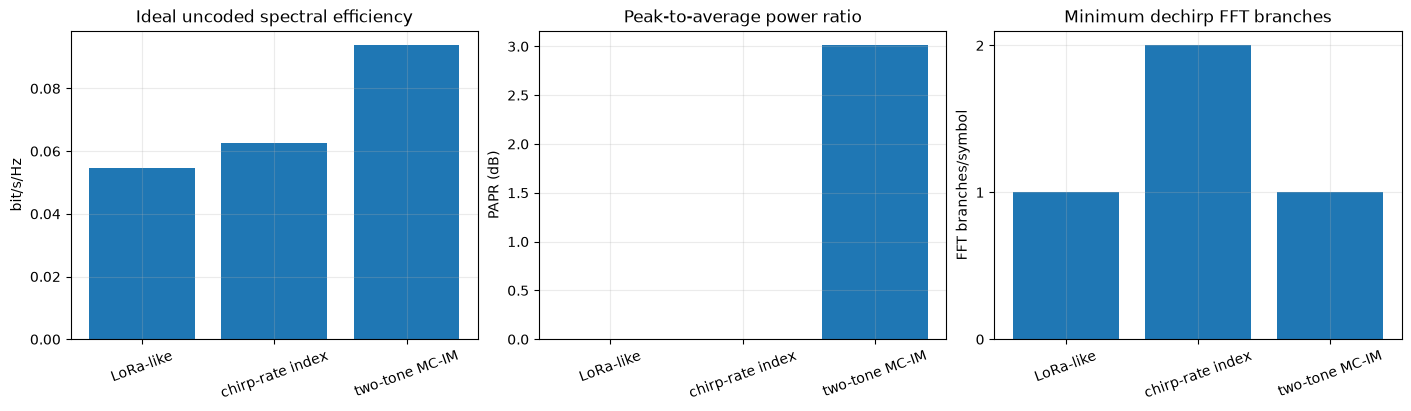

LoRa-like           :  7 bits/symbol, 0.0547 bit/s/Hz, PAPR 0.00 dB
chirp-rate index    :  8 bits/symbol, 0.0625 bit/s/Hz, PAPR 0.00 dB
two-tone MC-IM      : 12 bits/symbol, 0.0938 bit/s/Hz, PAPR 3.01 dB


In [5]:
waveform_names = ("LoRa-like", "chirp-rate index", "two-tone MC-IM")
example_waveforms = (lora_waveform(21), ssk_waveform(21, 1), mcim_waveform(21))
bits_per_symbol = np.array([SF, SF + 1, MCIM_BITS])
spectral_efficiency = bits_per_symbol / M
papr_values_db = np.array([papr_db(waveform) for waveform in example_waveforms])
fft_branches = np.array([1, 2, 1])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
axes[0].bar(waveform_names, spectral_efficiency)
axes[0].set(title="Ideal uncoded spectral efficiency", ylabel="bit/s/Hz")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(waveform_names, papr_values_db)
axes[1].set(title="Peak-to-average power ratio", ylabel="PAPR (dB)")
axes[1].tick_params(axis="x", rotation=20)
axes[2].bar(waveform_names, fft_branches)
axes[2].set(title="Minimum dechirp FFT branches", ylabel="FFT branches/symbol", yticks=(0, 1, 2))
axes[2].tick_params(axis="x", rotation=20)
plt.show()

for name, bits, efficiency, papr in zip(waveform_names, bits_per_symbol, spectral_efficiency, papr_values_db):
    print(f"{name:20s}: {bits:2d} bits/symbol, {efficiency:.4f} bit/s/Hz, PAPR {papr:.2f} dB")


### See the waveform and the decision evidence

The top row plots instantaneous power. A single ideal chirp has constant envelope; adding two chirps produces beating and peaks. The bottom row shows matched dechirp spectra: one peak for LoRa-like CSS, a peak in the selected up/down reference branch for SSK, and two peaks for MC-IM. The extra bit in SSK selects a branch, not another simultaneous subcarrier. Multiple active chirps are a research waveform; a standard LoRa modem does not transmit SF7-SF12 simultaneously as OFDM subcarriers.

For a battery sensor, low PAPR can reduce amplifier backoff requirements. Actual energy efficiency still depends on PA design, coding, airtime, and retries. The AWGN comparison below holds symbol energy fixed while bits per symbol differ; it is not an equal-$E_b$ comparison. With $b$ bits per symbol, $E_b/N_0=SNR\,M/b$.

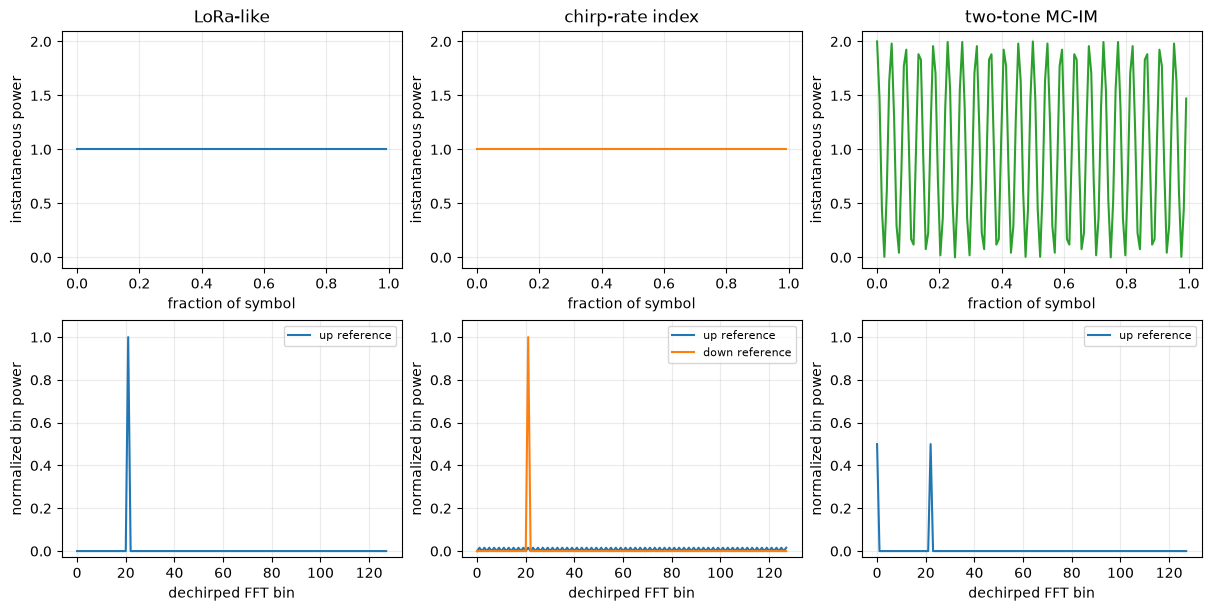

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
for col, (name, waveform) in enumerate(zip(waveform_names, example_waveforms)):
    axes[0, col].plot(N / M, np.abs(waveform)**2, color=f'C{col}')
    axes[0, col].set(title=name, xlabel='fraction of symbol', ylabel='instantaneous power', ylim=(-0.1, 2.1))
    references = ((UPCHIRP, 'up reference'), (DOWNCHIRP, 'down reference')) if col == 1 else ((UPCHIRP, 'up reference'),)
    for reference, label in references:
        power = np.abs(np.fft.fft(waveform * reference.conj()) / M)**2
        axes[1, col].plot(np.arange(M), power, label=label)
    axes[1, col].set(xlabel='dechirped FFT bin', ylabel='normalized bin power', ylim=(-0.03, 1.08))
    axes[1, col].legend(fontsize=8)
    assert np.isclose(np.mean(np.abs(waveform)**2), 1)
plt.show()

## 6. Symbol error in AWGN

Every transmitted waveform is normalized to the same average symbol power. An error means any information carried by that composite symbol is wrong: the LoRa tone, either SSK field, or either MC-IM tone. MC-IM carries more bits, but detecting both weaker component peaks is harder.


One downward triangle per waveform denotes the one-sided 95% upper bound at its first zero-error point; later zero-error points are omitted. This is not measured zero SER. Composite SER counts any error in a symbol; it is not BER or decoded packet BLER.

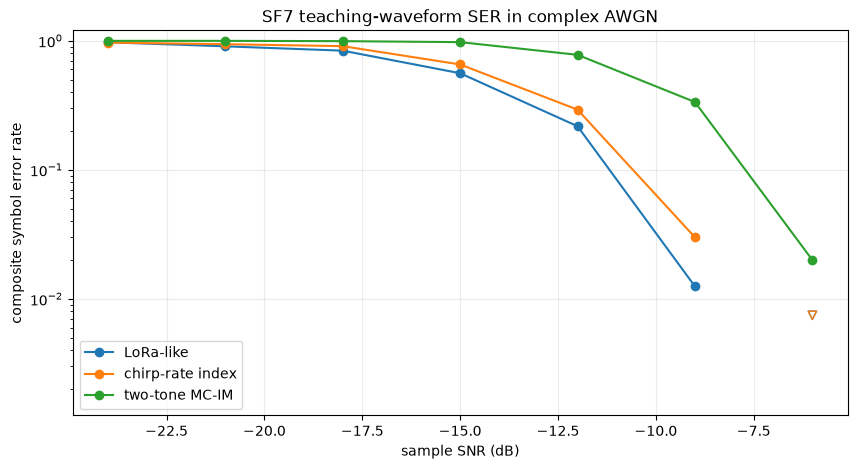

In [7]:
SNR_DB = np.arange(-24, -5, 3)
TRIALS = 400
rng = np.random.default_rng(8008)

def simulate_variant_ser(variant):
    output = []
    for snr_db in SNR_DB:
        errors = 0
        for _ in range(TRIALS):
            if variant == "lora":
                sent = int(rng.integers(M))
                waveform = lora_waveform(sent)
                correct = lambda samples: detect_lora(samples) == sent
            elif variant == "ssk":
                sent = int(rng.integers(M))
                chirp_bit = int(rng.integers(2))
                waveform = ssk_waveform(sent, chirp_bit)
                correct = lambda samples: detect_ssk(samples) == (sent, chirp_bit)
            else:
                sent = int(rng.integers(len(MCIM_PAIRS)))
                waveform = mcim_waveform(sent)
                correct = lambda samples: detect_mcim(samples) == sent
            errors += not correct(add_awgn(waveform, snr_db, rng))
        output.append(errors / TRIALS)
    return np.asarray(output)

variant_ser = {name: simulate_variant_ser(key) for name, key in zip(waveform_names, ("lora", "ssk", "mcim"))}
fig, ax = plt.subplots(figsize=(10, 5))
floor = 1 / (2 * TRIALS)
for name, ser in variant_ser.items():
    line, = ax.semilogy(SNR_DB, np.where(ser > 0, ser, np.nan), marker="o", label=name)
    first_zero = np.flatnonzero(ser == 0)[:1]
    ax.scatter(SNR_DB[first_zero], np.full(first_zero.size, 1 - 0.05 ** (1 / TRIALS)), marker="v", facecolors="none", edgecolors=line.get_color())
ax.set(title=f"SF{SF} teaching-waveform SER in complex AWGN", xlabel="sample SNR (dB)", ylabel="composite symbol error rate", ylim=(floor, 1.2))
ax.legend()
plt.show()

assert variant_ser["two-tone MC-IM"][-2] > variant_ser["LoRa-like"][-2]

## 7. Interpret the trade-offs carefully

- The chirp-rate index adds one bit while preserving constant envelope, but doubles the reference-search work and introduces chirp-rate discrimination errors.
- Two-frequency index modulation increases bits per symbol, but each component has half the symbol energy and both bins must be recovered. Its 3 dB PAPR can also force power-amplifier backoff.
- Spectral efficiency alone does not determine battery life. Receiver FFT work, PA efficiency, retransmissions, synchronization, and coding also matter.
- These ideal AWGN curves omit frequency offset, phase noise, multipath, nonlinear PA distortion, packet acquisition, and coding. Those omissions can change the ranking.
- A custom CSS variant is not LoRa interoperability. It must use a custom PHY implementation, spectrum evaluation, and an appropriate regulatory profile.


## Focused references

- A. W. Azim et al., [Chirp Spread Spectrum-Based Waveform Design and Detection Mechanisms for LPWAN-Based IoT: A Survey](https://doi.org/10.1109/ACCESS.2024.3352591), IEEE Access, 2024. Read its single-chirp, multiple-chirp, and index-modulation comparisons, including PAPR and detector complexity.
- M. Chiani and A. Elzanaty, [On the LoRa Modulation for IoT: Waveform Properties and Spectral Analysis](https://arxiv.org/abs/1906.04256): a mathematical baseline for waveform and spectral comparisons.